# Semana 12 - Aprender Matplotlib

**Propósito de la clase:** aprender a crear gráficos claros con Python y Matplotlib, interpretar lo que muestran y decidir qué tipo de gráfico conviene usar según la pregunta de análisis.

## Qué voy a aprender

Al finalizar este notebook usted podrá:

- Crear gráficos de líneas, barras, dispersión e histogramas.
- Identificar las partes de un gráfico: figura, ejes, título, etiquetas, escala, color, marcadores y leyenda.
- Personalizar un gráfico para que comunique mejor una idea.
- Usar `plt` para gráficos rápidos y `fig, ax` para gráficos más ordenados.
- Leer un CSV con `pandas` y visualizar datos reales de nacimientos y defunciones.


## Diagnóstico rápido

Antes de ejecutar código, responda en una frase:

1. ¿Qué diferencia hay entre el eje X y el eje Y?
2. ¿Qué tipo de gráfico usaría para mostrar cambios durante varios años?
3. ¿Qué problema tiene un gráfico sin título ni etiquetas?


## 1. Preparación

Ejecute esta celda al inicio. Si alguna biblioteca no está instalada, use en una terminal:

```bash
pip install matplotlib pandas
```


In [4]:
pip install matplotlib pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\CRIS\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [10]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")


## 2. Primer gráfico de líneas

**Concepto:** un gráfico de líneas permite observar cómo cambia una variable en una secuencia. Es muy útil para datos en el tiempo.

**Pregunta guía:** ¿cómo cambiaron las ventas durante el primer semestre?

**Prediga antes de ejecutar:** ¿en qué mes cree que la línea quedará más alta?


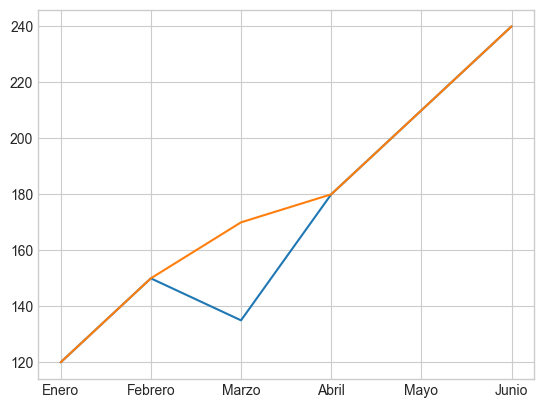

In [8]:
meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio"]
ventas = [120, 150, 135, 180, 210, 240]

plt.plot(meses,ventas)
plt.show

# Cambiamos el valor en la posición 2 (Marzo)
ventas[2] = 170

# Graficamos con el dato actualizado
plt.plot(meses, ventas)
plt.show() # Not


**Interpretación:** la línea permite ver una tendencia general de aumento, aunque marzo baja respecto a febrero.

**Micro-reto:** cambie el valor de marzo a `170` y vuelva a ejecutar. ¿Cómo cambia la forma de la línea?


## 3. Partes de un gráfico

Un gráfico claro normalmente necesita:

- **Figura:** espacio completo donde se dibuja.
- **Ejes:** área donde aparecen los datos.
- **Título:** indica la idea principal.
- **Etiqueta del eje X:** explica la variable horizontal.
- **Etiqueta del eje Y:** explica la variable vertical.
- **Leyenda:** identifica cada serie cuando hay más de una.
- **Escala:** define los valores visibles.


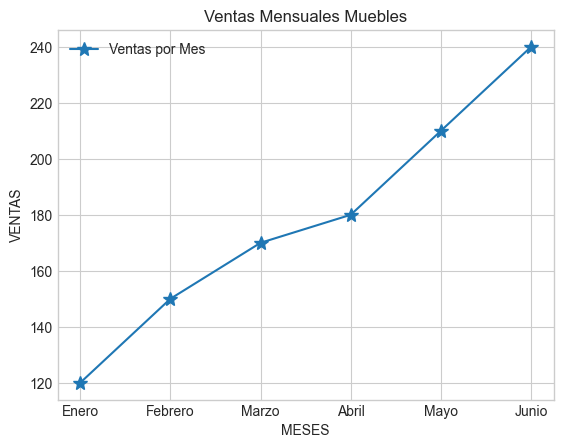

In [3]:
plt.plot(meses, ventas, marker="*", label="Ventas por Mes", markersize=10)
plt.title("Ventas Mensuales Muebles")
plt.xlabel("MESES")
plt.ylabel("VENTAS")
plt.legend()
plt.show()


**Observe:** el gráfico comunica mejor porque ahora indica qué representa cada eje y qué significa la línea.

**Micro-reto:** cambie el título para que sea más específico para una tienda o producto.


## 4. Comparar dos series con leyenda

**Concepto:** cuando se comparan dos grupos, la leyenda y los colores ayudan a distinguirlos.

**Pregunta guía:** ¿cuál tienda vendió más en la mayoría de meses?


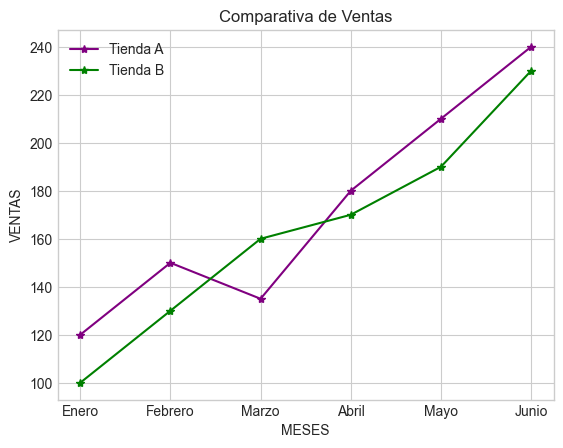

In [12]:
ventas_tienda_a = [120, 150, 135, 180, 210, 240]
ventas_tienda_b = [100, 130, 160, 170, 190, 230]


plt.plot(meses,ventas_tienda_a, marker="*", label="Tienda A", color="purple")
plt.plot(meses,ventas_tienda_b, marker="*", label="Tienda B", color="green")
plt.title("Comparativa de Ventas")
plt.xlabel("MESES")
plt.ylabel("VENTAS")
plt.legend()
plt.show()


**Interpretación:** la Tienda A tiene valores mayores en casi todos los meses, excepto marzo.

**Micro-reto:** agregue una tercera tienda con una nueva lista llamada `ventas_tienda_c`.


## 5. Límites, rotación y escala

**Concepto:** los límites ayudan a enfocar la lectura, pero pueden cambiar la percepción del gráfico. Deben usarse con cuidado.

**Pregunta guía:** ¿qué pasa si el eje Y empieza en 100 en lugar de 0?


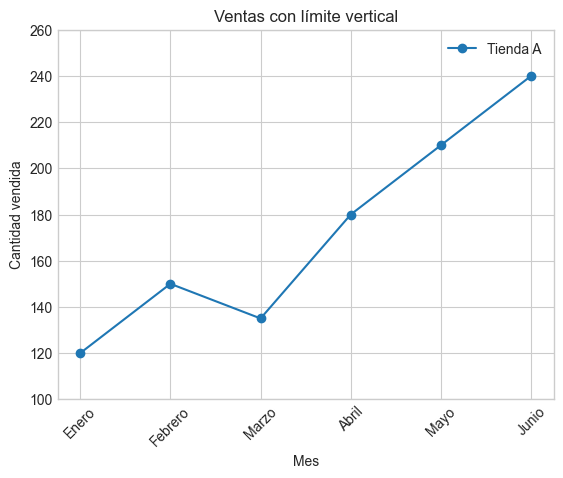

In [ ]:
plt.plot(meses, ventas_tienda_a, marker="o", label="Tienda A")

#Agragar limite vertical y Rotar etiquetas del eje x
plt.ylim(100,260) #ayuda a alejar o acercar el rango para graficar
plt.xticks(rotation=45) #cambia posicion de etiquetas  en eje x

plt.title("Ventas con límite vertical")
plt.xlabel("Mes")
plt.ylabel("Cantidad vendida")
plt.legend()
plt.show()


**Reflexión:** limitar el eje Y puede hacer que los cambios parezcan más grandes. En reportes, explique cuando usa una escala recortada.

**Micro-reto:** cambie `plt.ylim(100, 260)` por `plt.ylim(0, 260)` y compare.


## 6. Estilos de línea y marcadores

**Concepto:** los estilos permiten distinguir series y mejorar la lectura sin depender solo del color.


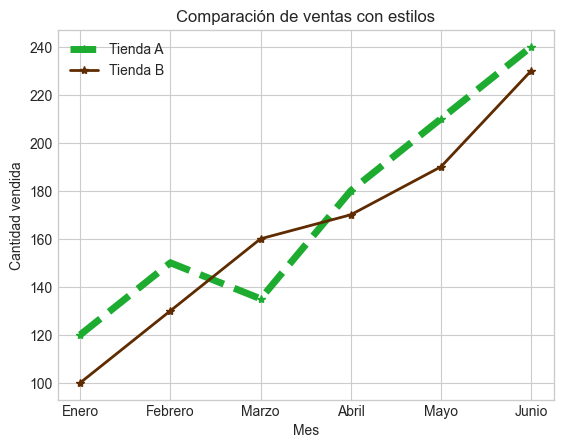

In [14]:
#Comparar estilos
plt.plot(meses,ventas_tienda_a, marker="*", label="Tienda A", color="#1DAC30", linestyle="--", linewidth=5, markersize=6)
plt.plot(meses,ventas_tienda_b, marker="*", label="Tienda B", color="#5f2b00", linestyle="-", linewidth=2, markersize=6)



plt.title("Comparación de ventas con estilos")
plt.xlabel("Mes")
plt.ylabel("Cantidad vendida")
plt.legend()
plt.show()


**Micro-reto:** cambie el estilo de línea de la Tienda B a `":"` y el marcador a `"^"`.


## 7. Gráfico de barras

**Cuándo usarlo:** cuando se comparan categorías, no una secuencia continua.

**Pregunta guía:** ¿qué producto tuvo más unidades vendidas?


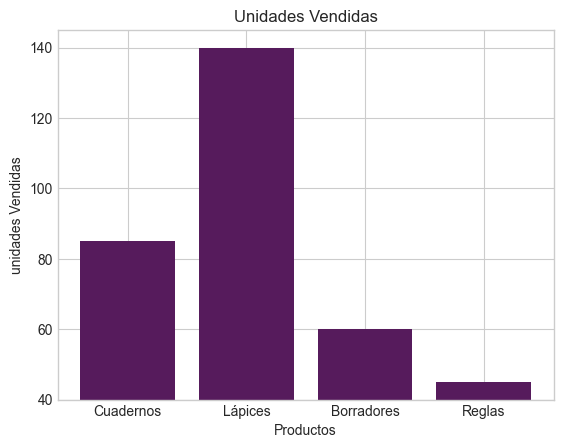

In [14]:



productos = ["Cuadernos", "Lápices", "Borradores", "Reglas"]
unidades = [85, 140, 60, 45]

#funciona para darle mejor proyeccion al grafico, saca los minimos y maximos para que el grafico sea mas realista
min_valor = min(unidades) - 5
max_valor = max(unidades) + 5
plt.ylim(min_valor, max_valor)

plt.bar(productos, unidades, color="#561b5c")
plt.title("Unidades Vendidas")
plt.xlabel("Productos")
plt.ylabel("unidades Vendidas")
plt.show()


**Interpretación:** los lápices son el producto con más unidades vendidas.

**Micro-reto:** ordene visualmente los productos de mayor a menor creando nuevas listas ordenadas.


## 8. Gráfico de dispersión

**Cuándo usarlo:** cuando se quiere observar la relación entre dos variables numéricas.

**Pregunta guía:** ¿parece haber relación entre horas de estudio y calificación?


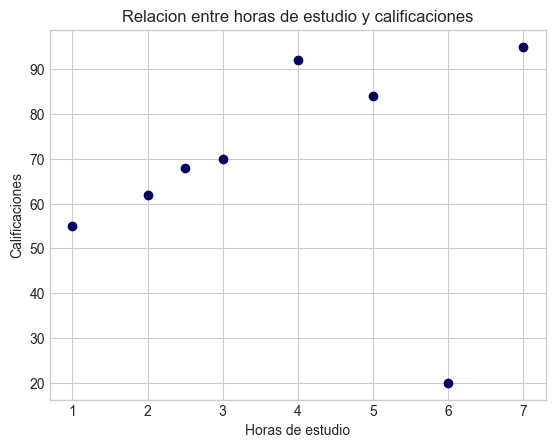

In [21]:
horas_estudio = [1, 2, 2.5, 3, 4, 5, 6, 7]
calificaciones = [55, 62, 68, 70, 92, 84, 20, 95,]

plt.scatter(horas_estudio, calificaciones, color="#00005f")
plt.title("Relacion entre horas de estudio y calificaciones")
plt.ylabel("Calificaciones")
plt.xlabel("Horas de estudio")
plt.show()



**Interpretación:** los puntos sugieren una relación positiva: cuando aumentan las horas de estudio, también sube la calificación.

**Micro-reto:** agregue un estudiante con 8 horas de estudio y calificación 98.


## 9. Histograma

**Cuándo usarlo:** cuando se desea ver la distribución de una variable numérica.

**Pregunta guía:** ¿en qué rango de edad hay más estudiantes?


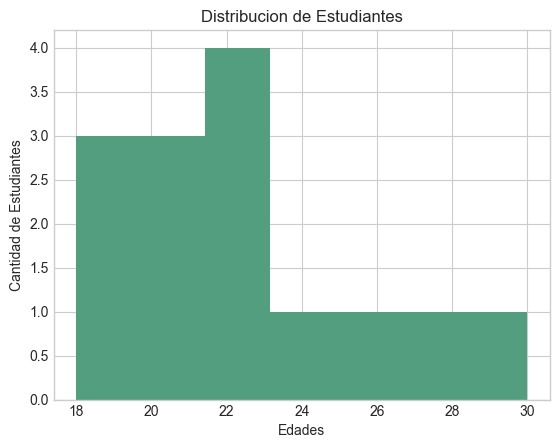

In [6]:
edades = [18, 19, 19, 20, 21, 21, 22, 22, 22, 23, 24, 25, 27, 30]

plt.hist(edades, bins=7, color= "#539e7f" )
plt.title("Distribucion de Estudiantes")
plt.xlabel("Edades")
plt.ylabel("Cantidad de Estudiantes")
plt.show()

**Micro-reto:** cambie `bins=5` por `bins=3` y luego por `bins=8`. ¿Cuál versión se entiende mejor?


## 10. Errores comunes y cómo corregirlos

El siguiente gráfico funciona, pero comunica mal porque no tiene contexto.


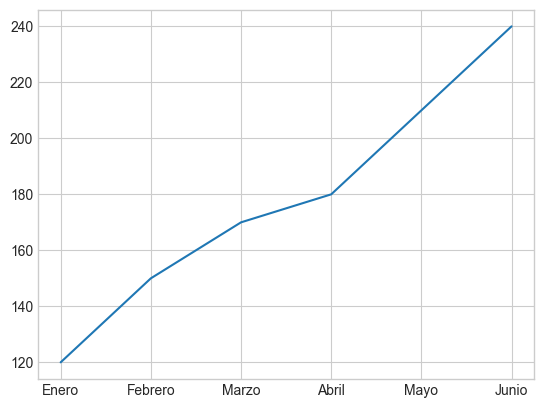

In [9]:
plt.plot(meses, ventas)
plt.show()


Una versión más clara agrega título, etiquetas, marcador y tamaño.


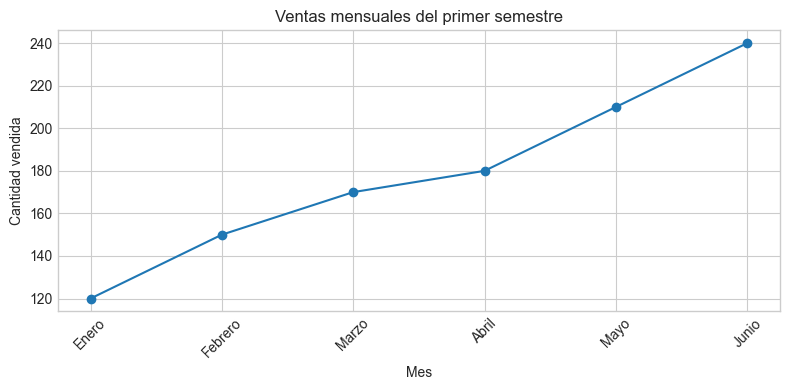

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(meses, ventas, marker="o", color="tab:blue")
plt.title("Ventas mensuales del primer semestre")
plt.xlabel("Mes")
plt.ylabel("Cantidad vendida")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 11. Subgráficos

**Concepto:** los subgráficos permiten mostrar varias visualizaciones relacionadas en una misma figura.


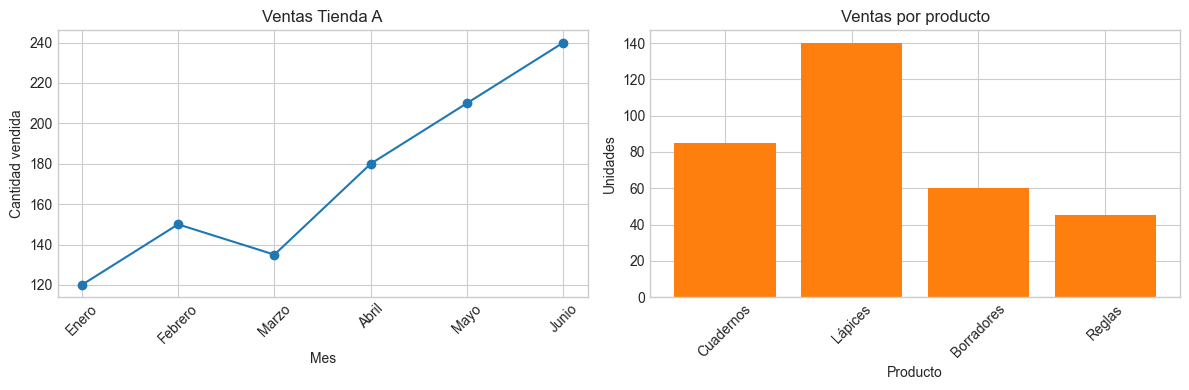

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(meses, ventas_tienda_a, marker="o", color="tab:blue")
axes[0].set_title("Ventas Tienda A")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("Cantidad vendida")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(productos, unidades, color="tab:orange")
axes[1].set_title("Ventas por producto")
axes[1].set_xlabel("Producto")
axes[1].set_ylabel("Unidades")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


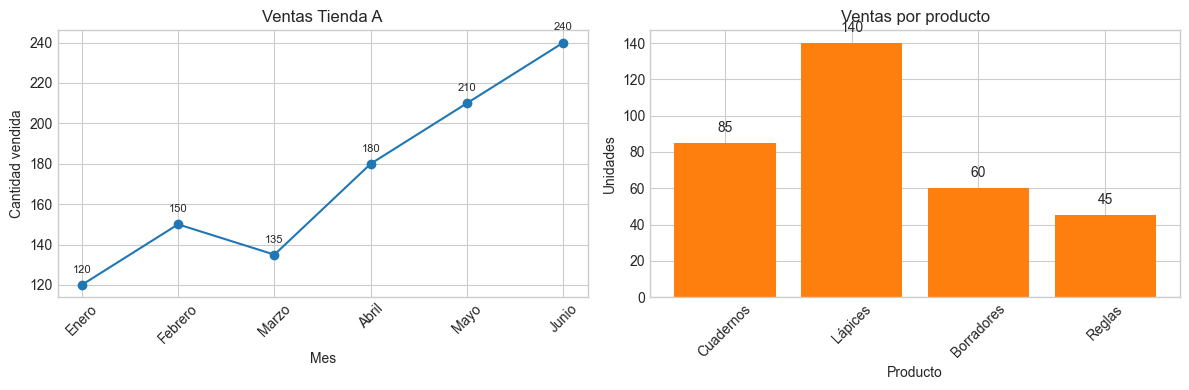

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


axes[0].plot(meses, ventas_tienda_a, marker="o", color="tab:blue")
axes[0].set_title("Ventas Tienda A")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("Cantidad vendida")
axes[0].tick_params(axis="x", rotation=45)


for x, y in zip(meses, ventas_tienda_a):
    axes[0].text(x, y + 5, str(y), ha="center", va="bottom", fontsize=8)    


axes[1].bar(productos, unidades, color="tab:orange")
axes[1].set_title("Ventas por producto")
axes[1].set_xlabel("Producto")
axes[1].set_ylabel("Unidades")
axes[1].tick_params(axis="x", rotation=45)
# Mostrar valor en cada punto
for x, y in zip(productos, unidades):
    axes[1].annotate(
        str(y),           # texto a mostrar
        xy=(x, y),        # punto real
        xytext=(0, 8),    # separacion del texto
        textcoords="offset points",
        ha="center"
    )



plt.tight_layout()
plt.show()

**Micro-reto:** cambie la figura para que tenga 2 filas y 1 columna usando `plt.subplots(2, 1, figsize=(8, 8))`.


## 12. Interfaz orientada a objetos: `fig` y `ax`

Para trabajos más ordenados se recomienda crear `fig` y `ax`. Esta forma facilita personalizar y reutilizar gráficos.


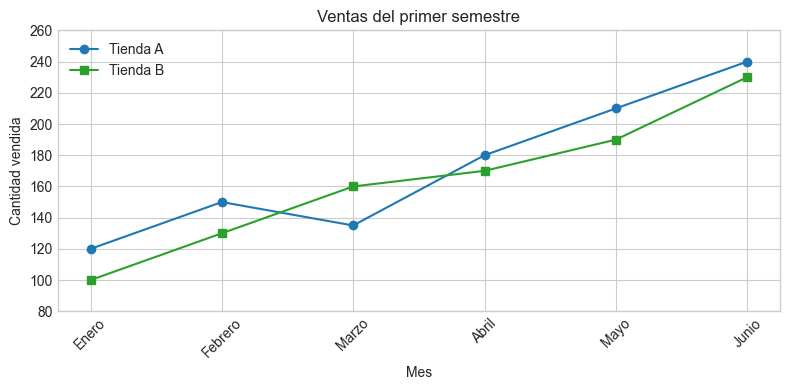

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(meses, ventas_tienda_a, marker="o", color="tab:blue", label="Tienda A")
ax.plot(meses, ventas_tienda_b, marker="s", color="tab:green", label="Tienda B")

ax.set_title("Ventas del primer semestre")
ax.set_xlabel("Mes")
ax.set_ylabel("Cantidad vendida")
ax.set_ylim(80, 260)
ax.legend()
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## 13. Buenas prácticas visuales

Use esta lista cada vez que termine un gráfico:

- El título responde qué se está mostrando.
- El eje X y el eje Y tienen etiquetas claras.
- Si hay más de una serie, existe leyenda.
- Los colores ayudan a comparar, no decoran sin propósito.
- La escala no exagera ni oculta cambios importantes.
- `plt.tight_layout()` evita que textos se corten.


## 14. Aplicación con datos reales

Ahora se usará el archivo `nacimientos_defunciones.csv`, ubicado en esta misma carpeta.

**Pregunta guía:** ¿cómo han cambiado los nacimientos y las defunciones entre 1950 y 2021?


In [8]:
import pandas as pd

df = pd.read_csv("nacimientos_defunciones.csv")
df.info()
print("Dimensiones Dataframe", df.shape)
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Año          72 non-null     int64
 1   Nacimientos  72 non-null     int64
 2   Defunciones  72 non-null     int64
dtypes: int64(3)
memory usage: 1.8 KB
Dimensiones Dataframe (72, 3)


,Año,Nacimientos,Defunciones
0,1950,37248,9769
1,1951,39239,9631
2,1952,42461,9902
3,1953,42817,10312
4,1954,48157,9713


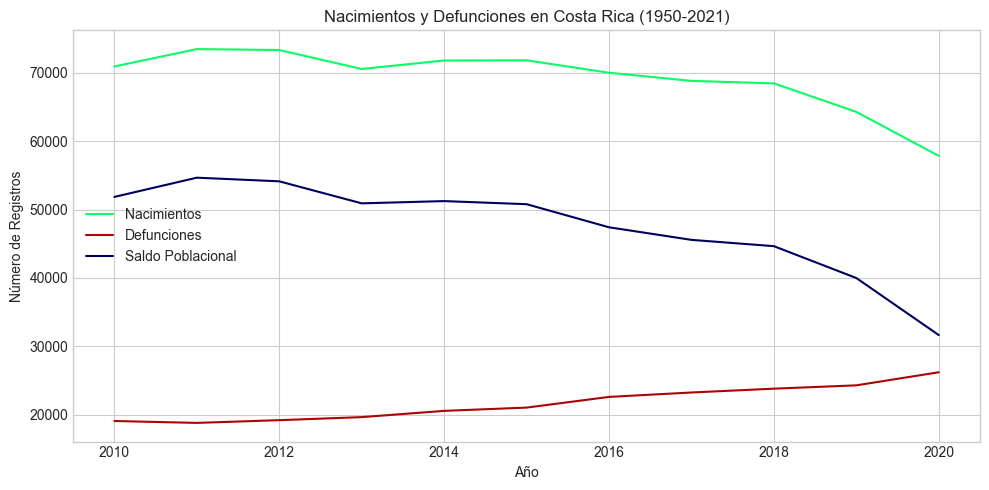

In [14]:
#Definir el tamaño de la figura y el eje
fig,ax = plt.subplots(figsize=(10, 5))



#Crear un filtro para seleccionar los años entre 2010 y 2020
filtro = (df["Año"] >= 2010) & (df["Año"] <= 2020)


#Estraer columnas del DataFrame para los años filtrados
anios = df[filtro]['Año']
nacimientos = df[filtro]["Nacimientos"]
defunciones = df[filtro]["Defunciones"]
saldo_poblacional = nacimientos - defunciones


#Graficar ambas series en el mismo eje
ax.plot(anios, nacimientos, label="Nacimientos", color="#0AFC67")
ax.plot(anios, defunciones, label="Defunciones", color="#AC0303")
ax.plot(anios,saldo_poblacional, label="Saldo Poblacional", color="#00005f")


#Configurar títulos y etiquetas
ax.set_title("Nacimientos y Defunciones en Costa Rica (1950-2021)")
ax.set_xlabel("Año")
ax.set_ylabel("Número de Registros")
ax.legend()


#Dibujar grafico y ajustar el diseño para evitar solapamientos
plt.tight_layout()
plt.show()

**Interpretación guiada:** observe si las líneas suben, bajan o se mantienen. También revise si la distancia entre nacimientos y defunciones cambia con el tiempo.

**Micro-reto:** cree una columna llamada `Saldo Poblacional` restando `Defunciones` a `Nacimientos` y grafíquela.


## Cierre

Responda en su cuaderno o en una celda markdown:

1. ¿Qué tipo de gráfico usaría para comparar categorías?
2. ¿Qué tipo de gráfico usaría para ver cambios por año?
3. ¿Qué elemento visual le ayudó más a entender los datos?
4. ¿Qué duda le queda sobre Matplotlib?
